In [1]:
import numpy as np
import pandas as pd

data_fil = pd.read_csv('../data/mock_withfilament.csv')
data_gxs = pd.read_csv('../data/to_mock.csv')
print(data_fil.head())
print(data_gxs.head())

# Print data_gxs min and max coordinates
print("data_gxs min coordinates:")
print(data_gxs[['x', 'y', 'z']].min())
print("data_gxs max coordinates:")
print(data_gxs[['x', 'y', 'z']].max())


   id   ifil       dfil       long        vx        vy        vz      vx_s  \
0   0  40167   4.553721  17.433956 -0.411057 -0.139315 -0.900901 -0.411057   
1   1  40135  23.632212  48.270763 -0.009530 -0.018560  0.999782 -0.009530   
2   2  40135  11.512803  48.270763  0.337681 -0.309021  0.889088  0.337681   
3   3  40150  19.133562  24.687315  0.538855  0.707508 -0.457239  0.538855   
4   4  40136   2.747936  14.980529 -0.653020 -0.753986 -0.071210 -0.653020   

       vy_s      vz_s  
0 -0.139315 -0.900901  
1 -0.018560  0.999782  
2 -0.309021  0.889088  
3  0.707508 -0.457239  
4 -0.753986 -0.071210  
          x        y        z      vx      vy      vz  magstarsdssr
0   5.07982  54.8365  26.0467  134.67  -69.30 -348.55      -20.4510
1  25.54040  18.9353  29.7675 -280.47   37.10   66.41      -21.6621
2  11.52790  18.8106  38.0231 -264.39 -365.38   39.71      -20.2699
3  10.37660  43.5003  69.2261 -119.96 -167.24  220.22      -20.2940
4  26.45570  22.9552  42.7072 -539.48 -374.27  

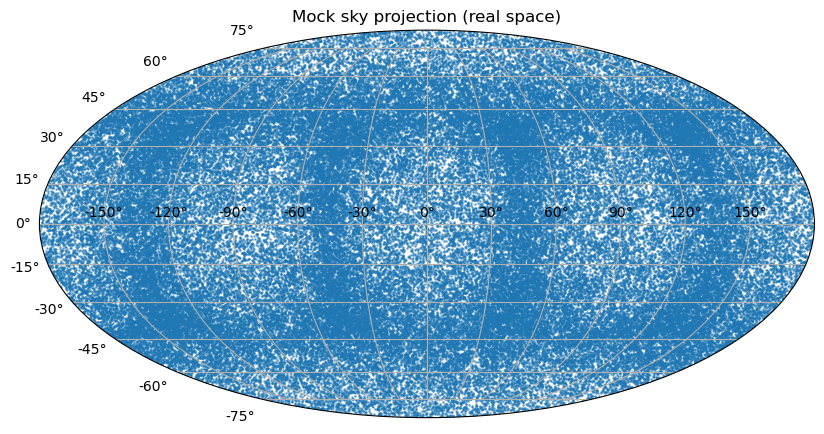

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/to_mock.csv")

x = df["x"].values
y = df["y"].values
z = df["z"].values

# --- Correct centering ---
x_c = x - 0.5 * (np.max(x) + np.min(x))
y_c = y - 0.5 * (np.max(y) + np.min(y))
z_c = z - 0.5 * (np.max(z) + np.min(z))

# Distance
r = np.sqrt(x_c**2 + y_c**2 + z_c**2)

# Angles
ra = np.degrees(np.arctan2(y_c, x_c))
ra = np.mod(ra, 360.0)

dec = np.degrees(np.arcsin(z_c / r))

# Convert to Mollweide coords
ra_rad = np.radians(ra - 180)
dec_rad = np.radians(dec)

# --- Proper dilution ---
idx = np.random.choice(len(ra_rad), size=len(ra_rad)//100, replace=False)

plt.figure(figsize=(10,6))
ax = plt.subplot(111, projection="mollweide")

ax.scatter(ra_rad[idx], dec_rad[idx], s=1, alpha=0.5)

ax.set_title("Mock sky projection (real space)")
ax.grid(True)

plt.show()

### Radial cut

Total galaxies in data_gxs: 12142272
Distance stats:
Min distance: 1.98 Mpc/h
Max distance: 864.33 Mpc/h
Galaxies after distance cut: 2845980
Galaxies after dilution: 28459


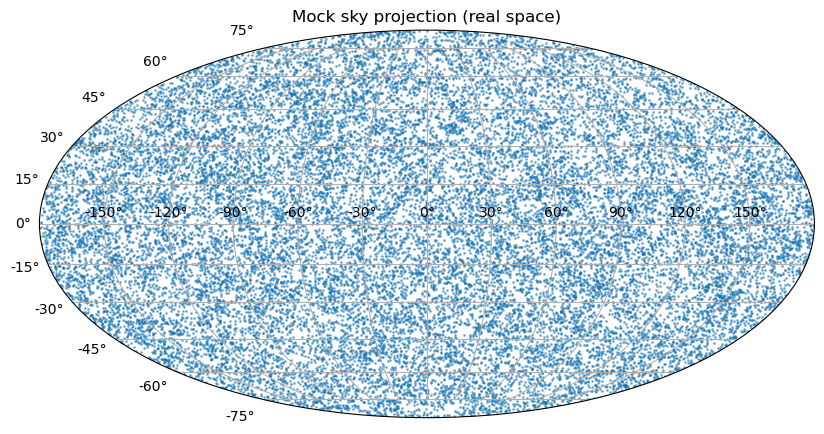

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/to_mock.csv")

print("Total galaxies in data_gxs:", len(df))

x = df["x"].values
y = df["y"].values
z = df["z"].values

# --- Correct centering ---
x_c = x - 0.5 * (np.max(x) + np.min(x))
y_c = y - 0.5 * (np.max(y) + np.min(y))
z_c = z - 0.5 * (np.max(z) + np.min(z))

# Distance
r = np.sqrt(x_c**2 + y_c**2 + z_c**2)

print("Distance stats:")
print(f"Min distance: {r.min():.2f} Mpc/h")
print(f"Max distance: {r.max():.2f} Mpc/h")

# Angles
ra = np.degrees(np.arctan2(y_c, x_c))
ra = np.mod(ra, 360.0)

dec = np.degrees(np.arcsin(z_c / r))

# Convert to Mollweide coords
ra_rad = np.radians(ra - 180)
dec_rad = np.radians(dec)

# Apply distance cut
r_min = 200   # Mpc/h (choose something reasonable)
r_max = 400

mask = (r > r_min) & (r < r_max)

ra_sel  = ra_rad[mask]
dec_sel = dec_rad[mask]

print("Galaxies after distance cut:", len(ra_sel))

# --- Proper dilution ---
idx = np.random.choice(len(ra_sel), size=len(ra_sel)//100, replace=False)

print("Galaxies after dilution:", len(idx))

plt.figure(figsize=(10,6))
ax = plt.subplot(111, projection="mollweide")

ax.scatter(ra_sel[idx], dec_sel[idx], s=1, alpha=0.5)

ax.set_title("Mock sky projection (real space)")
ax.grid(True)

plt.show()

### Assign cosmological redshift and RSD

In [ ]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d

# ============================================================
# 1. Load data and merge filament distances
# ============================================================

# Columns needed from the main file
main_cols = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'magstarsdssr']

# Use float32 (saves ~50% memory compared to float64)
dtype_main = {col: 'float32' for col in main_cols}

df = pd.read_csv("../data/to_mock.csv",
                 usecols=main_cols,
                 dtype=dtype_main)

# Filament file – only need the distance column
df_fil = pd.read_csv("../data/mock_withfilament.csv",
                     usecols=['dist_fil', 'dfil']  # load both to handle naming
                     # if you know which column exists, use only that one
                     )

# Attach dist_fil (handle both naming conventions)
if "dist_fil" in df_fil.columns:
    df["dist_fil"] = df_fil["dist_fil"].values
elif "dfil" in df_fil.columns:
    df["dist_fil"] = df_fil["dfil"].values
else:
    raise ValueError("No dist_fil/dfil column found in filament file")

print("Columns:", df.columns)

# ============================================================
# 2. Extract arrays
# ============================================================

x = df["x"].values
y = df["y"].values
z = df["z"].values

vx = df["vx"].values
vy = df["vy"].values
vz = df["vz"].values

dist_fil = df["dist_fil"].values

mag_r = df['magstarsdssr'].values

# ============================================================
# 3. Center coordinates around observer
# ============================================================

x_c = x - 0.5 * (np.max(x) + np.min(x))
y_c = y - 0.5 * (np.max(y) + np.min(y))
z_c = z - 0.5 * (np.max(z) + np.min(z))

# ============================================================
# 4. Compute distances and angles
# ============================================================

r = np.sqrt(x_c**2 + y_c**2 + z_c**2)

ra = np.degrees(np.arctan2(y_c, x_c))
ra = np.mod(ra, 360.0)

# Avoid division by zero
with np.errstate(invalid='ignore'):
    dec = np.degrees(np.arcsin(z_c / r))

ra_rad = np.radians(ra)
dec_rad = np.radians(dec)


# ============================================================
# 5. Cosmology: distance -> redshift
# ============================================================

cosmo = FlatLambdaCDM(H0=67.8, Om0=0.307)

z_grid = np.linspace(0, 1, 1000)
r_grid = cosmo.comoving_distance(z_grid).value
r_to_z = interp1d(r_grid, z_grid, bounds_error=False, fill_value="extrapolate")

z_cosmo = r_to_z(r)

# ============================================================
# 6. LOS velocities (RSD)
# ============================================================

nx = x_c / r
ny = y_c / r
nz = z_c / r

v_los = vx * nx + vy * ny + vz * nz

c = 3e5  # km/s
z_obs = z_cosmo + v_los / c

# ============================================================
# 7. Redshift+Magnitude cut
# ============================================================

zmin = 0.07
zmax = 0.12
mag_cut = -21.5
mask = (z_obs > zmin) & (z_obs < zmax) & (mag_r < mag_cut)

# Apply to everything
x_c = x_c[mask]
y_c = y_c[mask]
z_c = z_c[mask]

vx = vx[mask]
vy = vy[mask]
vz = vz[mask]

r = r[mask]

ra = ra[mask]
ra_rad = ra_rad[mask]
dec_rad = dec_rad[mask]

dist_fil = dist_fil[mask]
mag_r = mag_r[mask]

z_cosmo = z_cosmo[mask]
z_obs = z_obs[mask]

# ============================================================
# 8. Convert to redshift-space positions
# ============================================================

# Recompute unit vectors after angular mask
nx = x_c / r
ny = y_c / r
nz = z_c / r

r_obs = cosmo.comoving_distance(z_obs).value

x_rsd = r_obs * nx
y_rsd = r_obs * ny
z_rsd = r_obs * nz

# ============================================================
# 8. Angular selection – healpy mask
# ============================================================

nside = 256
npix = hp.nside2npix(nside)
occupied = np.zeros(npix, dtype=bool)   # boolean array is memory efficient

print('Reading Random Catalog and building HEALPix mask...')
# Read the random catalog in chunks
chunksize = 800_000  # adjust based on your available RAM
for chunk in pd.read_csv("../data/lss_randoms_combined_cut_LARGE.csv",
                         usecols=['ra', 'dec'],   # only need these columns
                         dtype={'ra': 'float32', 'dec': 'float32'},  # reduce precision
                         chunksize=chunksize):

    # Convert to radians and to HEALPix pixel indices
    theta = np.radians(90.0 - chunk['dec'].values)   # colatitude
    phi   = np.radians(chunk['ra'].values)           # longitude
    pix = hp.ang2pix(nside, theta, phi, nest=True)

    # Mark these pixels as occupied
    occupied[pix] = True   # vectorised, sets all corresponding pixels to True

    # Optional: explicitly free the chunk memory
    del chunk, theta, phi, pix

# Galaxy coordinates (already in radians for dec_rad, ra_rad)
theta_gal = np.pi/2.0 - dec_rad   # dec_rad is in radians (from your code)
phi_gal   = ra_rad                 # ra_rad in radians
pix_gal = hp.ang2pix(nside, theta_gal, phi_gal, nest=True)

# Mask: keep galaxies whose pixel is occupied
mask_ang = occupied[pix_gal]

# Apply the mask to all relevant arrays
x_c = x_c[mask_ang]
y_c = y_c[mask_ang]
z_c = z_c[mask_ang]
vx = vx[mask_ang]
vy = vy[mask_ang]
vz = vz[mask_ang]
r = r[mask_ang]
ra = ra[mask_ang]
ra_rad = ra_rad[mask_ang]
dec_rad = dec_rad[mask_ang]
dist_fil = dist_fil[mask_ang]
mag_r = mag_r[mask_ang]
z_cosmo = z_cosmo[mask_ang]
z_obs = z_obs[mask_ang]
x_rsd = x_rsd[mask_ang]
y_rsd = y_rsd[mask_ang]
z_rsd = z_rsd[mask_ang]
r_obs = r_obs[mask_ang]          
v_los = v_los[mask_ang]         

# ============================================================
# 10. Save lightcone catalog
# ============================================================

out_df = pd.DataFrame({
    "x_real": x_c,
    "y_real": y_c,
    "z_real": z_c,
    "x_rsd": x_rsd,
    "y_rsd": y_rsd,
    "z_rsd": z_rsd,
    "ra_deg": ra,
    "dec_deg": np.degrees(dec_rad),
    "z_cosmo": z_cosmo,
    "z_obs": z_obs,
    "dist_fil": dist_fil,
    "mag_r": mag_r
})

print(f"Number of galaxies: {len(out_df)}")

output_file = "../data/lightcone_real_and_rsd_withfil.csv"
out_df.to_csv(output_file, index=False)

print(f"Saved lightcone to: {output_file}")

print("Real space: x_c range: [{:.1f}, {:.1f}]".format(x_c.min(), x_c.max()))
print("Real space: r range: [{:.1f}, {:.1f}]".format(r.min(), r.max()))
print("Redshift space: x_rsd range: [{:.1f}, {:.1f}]".format(x_rsd.min(), x_rsd.max()))
print("Redshift space: r_obs range: [{:.1f}, {:.1f}]".format(r_obs.min(), r_obs.max()))
print("Any |x_rsd| > r_obs? :", np.any(np.abs(x_rsd) > r_obs))
print("v_los mean/std: {:.1f} / {:.1f} km/s".format(v_los.mean(), v_los.std()))
print("v_los max abs: {:.1f} km/s".format(np.abs(v_los).max()))

# ============================================================
# Plots
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# RA/Dec plot
plt.figure(figsize=(10,6))
plt.scatter(np.degrees(ra_rad), np.degrees(dec_rad), s=1, alpha=0.5)
plt.title("Light-cone sky projection (RA/Dec)")
plt.grid(True)
plt.show()


# --- Subsample for plotting (optional, for speed) ---
N_plot = min(5_000_000, len(x_c))
idx = np.random.choice(len(x_c), size=N_plot, replace=False)

# Transverse coordinate (X)
x_trans_real = x_c[idx]
x_trans_rsd  = x_rsd[idx]

# LOS distances
r_los_real = r[idx]       # real-space
r_los_rsd  = r_obs[idx]   # redshift-space

# --- 2D histogram parameters ---
bins_x = 150   # transverse bins
bins_y = 150   # LOS bins

vmin = None    # can fix min/max to same scale for both plots
vmax = None

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Real-space density
h0 = axes[0].hist2d(x_trans_real, r_los_real, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[0].set_xlabel("X [Mpc/h]")
axes[0].set_ylabel("LOS distance [Mpc/h]")
axes[0].set_title("Real-space projection")

# Redshift-space density
h1 = axes[1].hist2d(x_trans_rsd, r_los_rsd, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[1].set_xlabel("X [Mpc/h]")
axes[1].set_title("Redshift-space projection")

# Colorbars
fig.colorbar(h0[3], ax=axes[0], label="Density")
fig.colorbar(h1[3], ax=axes[1], label="Density")

plt.suptitle("Light-cone wedge plots (2D histogram)")
plt.tight_layout()
plt.savefig("../plots/lightcone_wedge_plots.png", dpi=100)
plt.show()

Number of galaxies: 398836
Saved lightcone to: ../data/lightcone_real_and_rsd_withfil.csv
Real space: x_c range: [-443.8, -27.8]
Real space: r range: [193.0, 455.7]
Redshift space: x_rsd range: [-433.4, -27.9]
Redshift space: r_obs range: [206.4, 433.6]


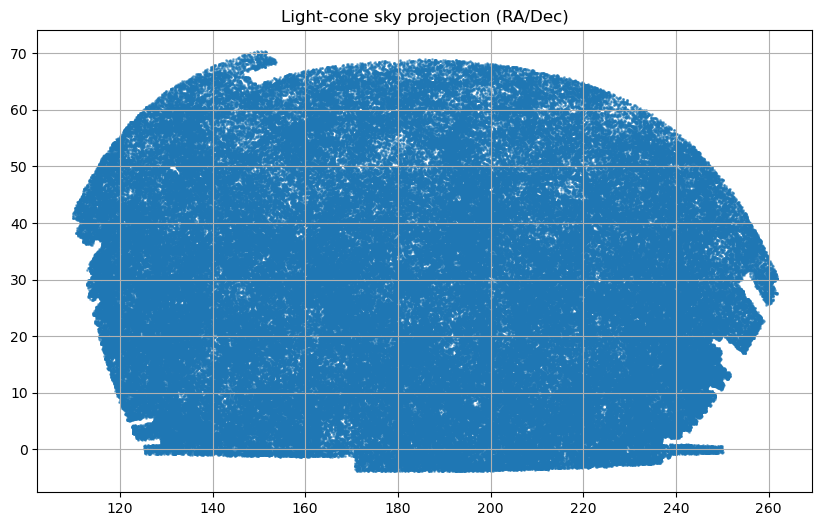

398836 398836


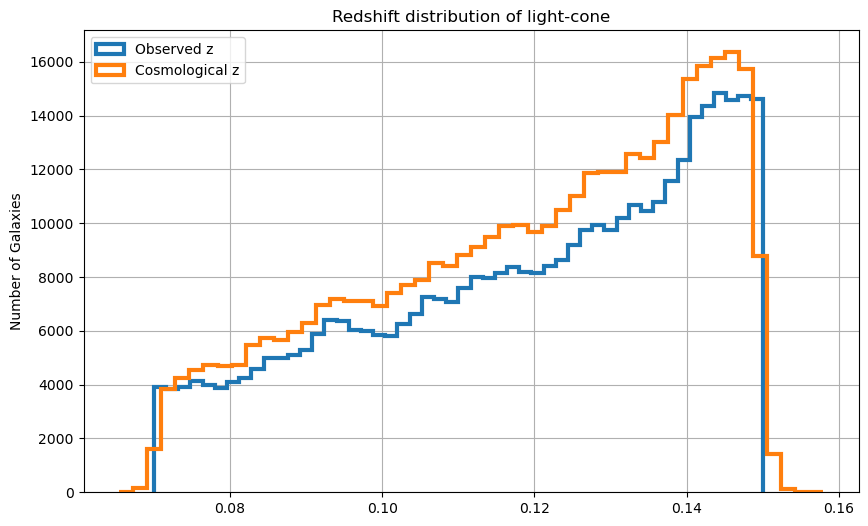

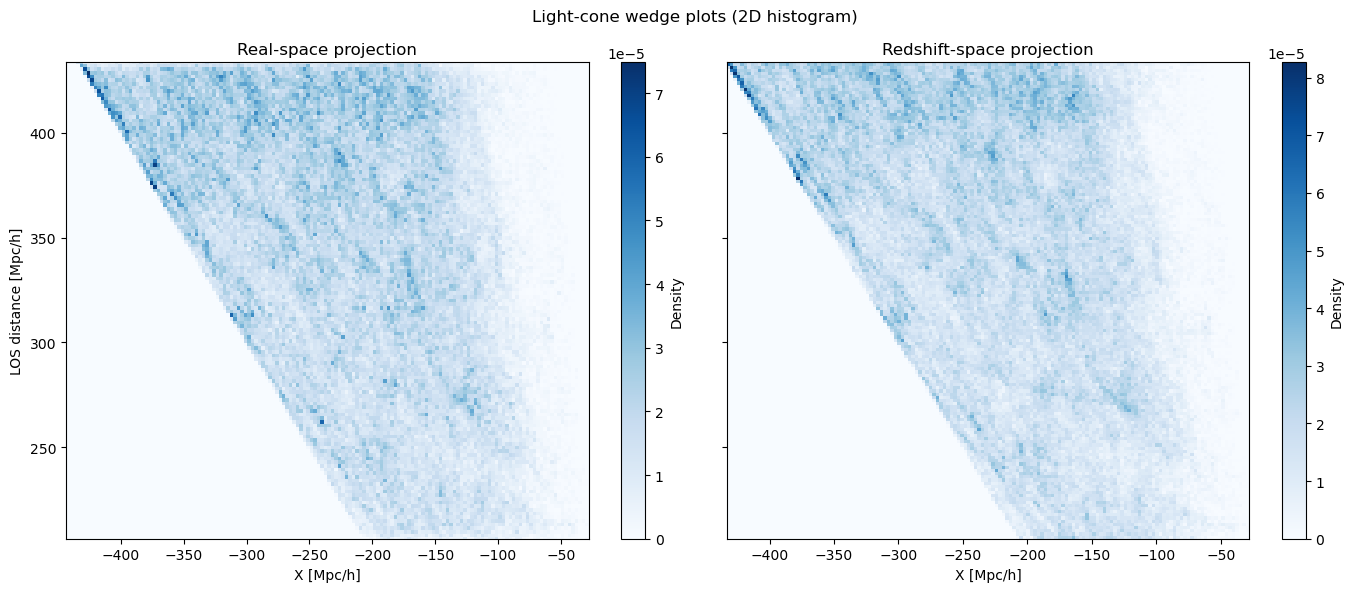

In [ ]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d

h = 1
Om0 = 0.31

# ============================================================
# 1. Build angular mask from random catalog (chunked)
# ============================================================
nside = 256
npix = hp.nside2npix(nside)
counts = np.zeros(npix, dtype=np.int32)   # counter array

chunksize_rand = 5_000_000
for chunk in pd.read_csv("../data/lss_randoms_combined_cut_LARGE.csv",
                         usecols=['ra', 'dec'],
                         dtype={'ra': 'float32', 'dec': 'float32'},
                         chunksize=chunksize_rand):
    theta = np.radians(90.0 - chunk['dec'].values)
    phi   = np.radians(chunk['ra'].values)
    pix = hp.ang2pix(nside, theta, phi, nest=True)
    # Increment counts for each pixel
    np.add.at(counts, pix, 1)
    del chunk, theta, phi, pix

# Set a threshold: keep only pixels with at least `min_rand` random points
min_rand = 5   # adjust based on your random catalog density
mask_pix = counts >= min_rand

# ============================================================
# 2. Process galaxy file in chunks
# ============================================================
# Columns needed from main file
main_cols = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'magstarsdssr']
dtype_main = {col: 'float32' for col in main_cols}

# Read filament file (assuming it's small – one column)
# If it's huge, we'll need to chunk it too, but let's assume it's manageable.
df_fil = pd.read_csv("../data/mock_withfilament.csv", usecols=['dfil'])
# Determine which column exists
if 'dist_fil' in df_fil.columns:
    dist_fil_all = df_fil['dist_fil'].values
elif 'dfil' in df_fil.columns:
    dist_fil_all = df_fil['dfil'].values
else:
    raise ValueError("No dist_fil/dfil column")
# Now we have an array of filament distances, same order as main file rows.
# We'll need to slice it per chunk. We'll keep an index counter.

# Cosmology
cosmo = FlatLambdaCDM(H0=h*100, Om0=Om0)
z_grid = np.linspace(0, 1, 1000)
r_grid = cosmo.comoving_distance(z_grid).value
r_to_z = interp1d(r_grid, z_grid, bounds_error=False, fill_value="extrapolate")
c = 3e5  # km/s

# Prepare to collect survivors
survivors = []  # list of dicts or small DataFrames

chunksize_gal = 1_000_000  # adjust based on your RAM
start_idx = 0

for chunk in pd.read_csv("../data/to_mock.csv",
                         usecols=main_cols,
                         dtype=dtype_main,
                         chunksize=chunksize_gal):
    # Extract arrays
    x = chunk['x'].values
    y = chunk['y'].values
    z = chunk['z'].values
    vx = chunk['vx'].values
    vy = chunk['vy'].values
    vz = chunk['vz'].values
    mag_r = chunk['magstarsdssr'].values

    # Corresponding filament distances for this chunk
    end_idx = start_idx + len(chunk)
    dist_fil_chunk = dist_fil_all[start_idx:end_idx]
    start_idx = end_idx

    # Center coordinates around observer
    L = 1000.0          # box size in Mpc/h
    x_c = x - L/2
    y_c = y - L/2
    z_c = z - L/2

    # Distances and angles
    r = np.sqrt(x_c**2 + y_c**2 + z_c**2)
    ra = np.degrees(np.arctan2(y_c, x_c))
    ra = np.mod(ra, 360.0)
    with np.errstate(invalid='ignore'):
        dec = np.degrees(np.arcsin(z_c / r))
    ra_rad = np.radians(ra)
    dec_rad = np.radians(dec)

    # Cosmological redshift
    z_cosmo = r_to_z(r)

    # LOS velocities
    nx = x_c / r
    ny = y_c / r
    nz = z_c / r
    v_los = vx * nx + vy * ny + vz * nz
    z_obs = z_cosmo + (1 + z_cosmo) * v_los / c

    # Redshift + magnitude cut
    mask_z_mag = (z_obs > 0.05) & (z_obs < 0.2) & (mag_r < -20.5)

    # Apply this cut now to reduce data size
    if not np.any(mask_z_mag):
        continue   # no survivors in this chunk

    x_c = x_c[mask_z_mag]
    y_c = y_c[mask_z_mag]
    z_c = z_c[mask_z_mag]
    vx = vx[mask_z_mag]
    vy = vy[mask_z_mag]
    vz = vz[mask_z_mag]
    r = r[mask_z_mag]
    ra = ra[mask_z_mag]
    ra_rad = ra_rad[mask_z_mag]
    dec_rad = dec_rad[mask_z_mag]
    dist_fil_chunk = dist_fil_chunk[mask_z_mag]
    mag_r = mag_r[mask_z_mag]
    z_cosmo = z_cosmo[mask_z_mag]
    z_obs = z_obs[mask_z_mag]

    # Recompute unit vectors after cut (optional, but safe)
    nx = x_c / r
    ny = y_c / r
    nz = z_c / r

    # Redshift-space positions
    r_obs = cosmo.comoving_distance(z_obs).value
    x_rsd = r_obs * nx
    y_rsd = r_obs * ny
    z_rsd = r_obs * nz

    # Angular mask – compute pixel indices and apply
    theta_gal = np.pi/2.0 - dec_rad
    phi_gal = ra_rad
    pix_gal = hp.ang2pix(nside, theta_gal, phi_gal, nest=True)
    mask_ang = mask_pix[pix_gal]
    if not np.any(mask_ang):
        continue

    # Apply angular mask
    x_c = x_c[mask_ang]
    y_c = y_c[mask_ang]
    z_c = z_c[mask_ang]
    vx = vx[mask_ang]
    vy = vy[mask_ang]
    vz = vz[mask_ang]
    r = r[mask_ang]
    ra = ra[mask_ang]
    ra_rad = ra_rad[mask_ang]
    dec_rad = dec_rad[mask_ang]
    dist_fil_chunk = dist_fil_chunk[mask_ang]
    mag_r = mag_r[mask_ang]
    z_cosmo = z_cosmo[mask_ang]
    z_obs = z_obs[mask_ang]
    x_rsd = x_rsd[mask_ang]
    y_rsd = y_rsd[mask_ang]
    z_rsd = z_rsd[mask_ang]

    # Store survivors (as dict or small DataFrame)
    chunk_survivors = pd.DataFrame({
        'x_real': x_c,
        'y_real': y_c,
        'z_real': z_c,
        'x_rsd': x_rsd,
        'y_rsd': y_rsd,
        'z_rsd': z_rsd,
        'ra_deg': ra,
        'dec_deg': np.degrees(dec_rad),
        'z_cosmo': z_cosmo,
        'z_obs': z_obs,
        'dist_fil': dist_fil_chunk,
        'mag_r': mag_r
    })
    survivors.append(chunk_survivors)

    # Optional: free chunk memory
    del chunk, x_c, y_c, z_c, vx, vy, vz, r, ra, ra_rad, dec_rad, dist_fil_chunk, mag_r, z_cosmo, z_obs, x_rsd, y_rsd, z_rsd

# ============================================================
# 3. Combine all survivors
# ============================================================
if not survivors:
    print("No galaxies passed the cuts.")
    exit()

out_df = pd.concat(survivors, ignore_index=True)
# final redshift cut
out_df = out_df[(out_df['z_obs'] > 0.07) & (out_df['z_obs'] < 0.15)]
print(f"Number of galaxies: {len(out_df)}")

# ============================================================
# 4. Save and plot
# ============================================================
output_file = "../data/lightcone_real_and_rsd_withfil.csv"
out_df.to_csv(output_file, index=False)
print(f"Saved lightcone to: {output_file}")

# Diagnostics
print("Real space: x_c range: [{:.1f}, {:.1f}]".format(out_df['x_real'].min(), out_df['x_real'].max()))
print("Real space: r range: [{:.1f}, {:.1f}]".format(np.sqrt(out_df['x_real']**2+out_df['y_real']**2+out_df['z_real']**2).min(),
                                                      np.sqrt(out_df['x_real']**2+out_df['y_real']**2+out_df['z_real']**2).max()))
print("Redshift space: x_rsd range: [{:.1f}, {:.1f}]".format(out_df['x_rsd'].min(), out_df['x_rsd'].max()))
print("Redshift space: r_obs range: [{:.1f}, {:.1f}]".format(np.sqrt(out_df['x_rsd']**2+out_df['y_rsd']**2+out_df['z_rsd']**2).min(),
                                                              np.sqrt(out_df['x_rsd']**2+out_df['y_rsd']**2+out_df['z_rsd']**2).max()))
#print("v_los mean/std: ...")  # you'd need to keep v_los if desired

# ============================================================
# Plots
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# RA/Dec plot using stored degrees
plt.figure(figsize=(10,6))
plt.scatter(out_df['ra_deg'], out_df['dec_deg'], s=1, alpha=0.5)
plt.title("Light-cone sky projection (RA/Dec)")
plt.grid(True)
plt.show()

# Redshift distribution
print(len(out_df['z_obs']), len(out_df['z_cosmo']))
plt.figure(figsize=(10,6))
plt.hist(out_df['z_obs'], bins=50, alpha=1, label='Observed z', histtype='step', lw=3)
plt.hist(out_df['z_cosmo'], bins=50, alpha=1, label='Cosmological z', histtype='step', lw=3)
plt.ylabel("Number of Galaxies")
plt.legend()
plt.title("Redshift distribution of light-cone")
plt.grid(True)
plt.show()

# Compute real-space and redshift-space distances
r_real = np.sqrt(out_df['x_real']**2 + out_df['y_real']**2 + out_df['z_real']**2)
r_obs  = np.sqrt(out_df['x_rsd']**2 + out_df['y_rsd']**2 + out_df['z_rsd']**2)

# Subsample for speed
N_plot = min(5_000_000, len(out_df))
idx = np.random.choice(len(out_df), size=N_plot, replace=False)

# Transverse coordinate (X)
x_trans_real = out_df['x_real'].values[idx]
x_trans_rsd  = out_df['x_rsd'].values[idx]

# LOS distances
r_los_real = r_real.values[idx]
r_los_rsd  = r_obs.values[idx]

# 2D histogram parameters
bins_x = 150
bins_y = 150
vmin = None
vmax = None

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Real-space density
h0 = axes[0].hist2d(x_trans_real, r_los_real, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[0].set_xlabel("X [Mpc/h]")
axes[0].set_ylabel("LOS distance [Mpc/h]")
axes[0].set_title("Real-space projection")

# Redshift-space density
h1 = axes[1].hist2d(x_trans_rsd, r_los_rsd, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[1].set_xlabel("X [Mpc/h]")
axes[1].set_title("Redshift-space projection")

# Colorbars
fig.colorbar(h0[3], ax=axes[0], label="Density")
fig.colorbar(h1[3], ax=axes[1], label="Density")

plt.suptitle("Light-cone wedge plots (2D histogram)")
plt.tight_layout()
plt.savefig("../plots/lightcone_wedge_plots.png", dpi=100)
plt.show()

### Applying periodic boundaries

Number of galaxies: 1003432
Saved lightcone to: ../data/lightcone_real_and_rsd_withfil.csv
Real space: x_c range: [-585.3, -25.2]
Real space: r range: [187.5, 602.6]
Redshift space: x_rsd range: [-570.5, -26.8]
Redshift space: r_obs range: [206.4, 570.9]


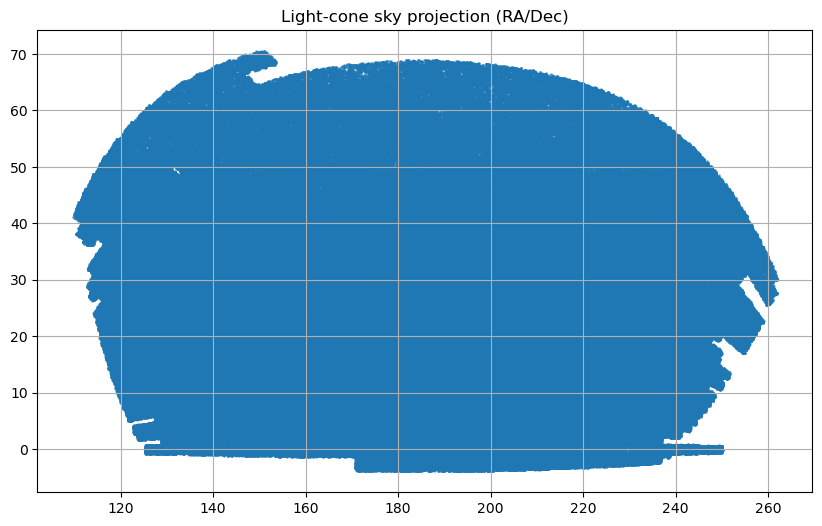

0.07000028455208539 0.19999976275539158 0.0634796071987316 0.21174117978583928


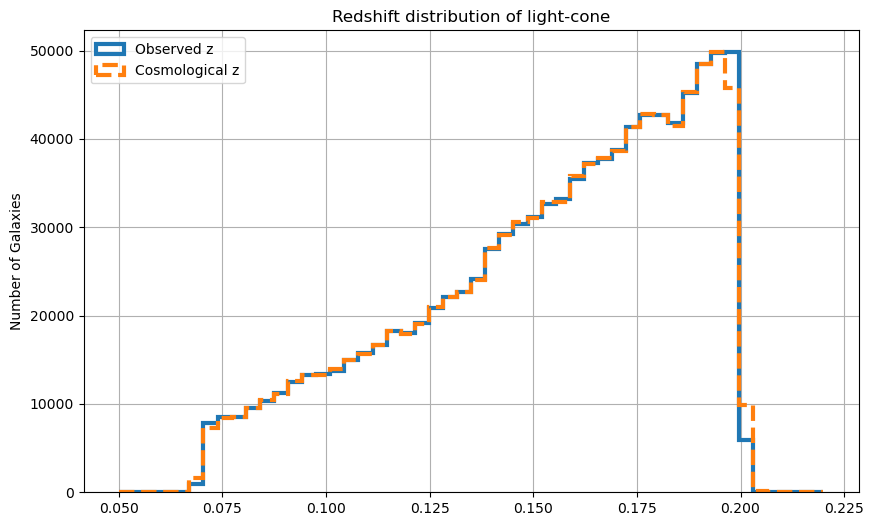

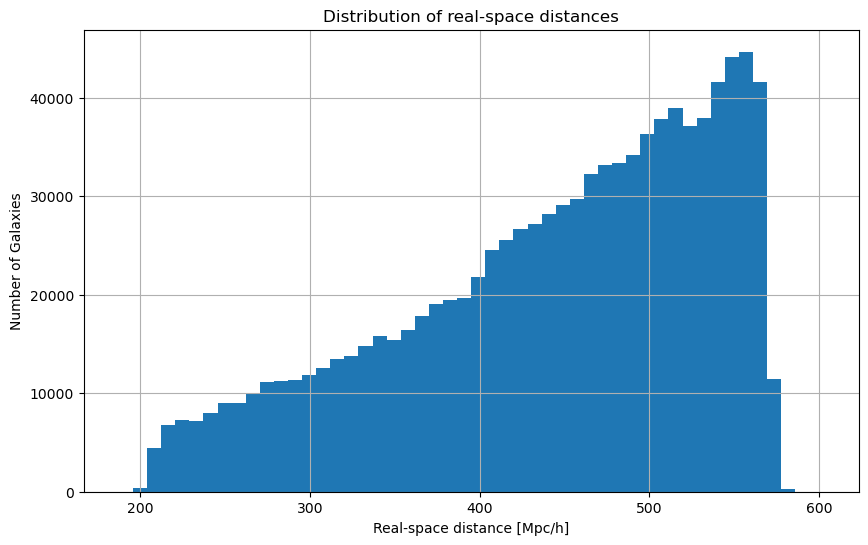

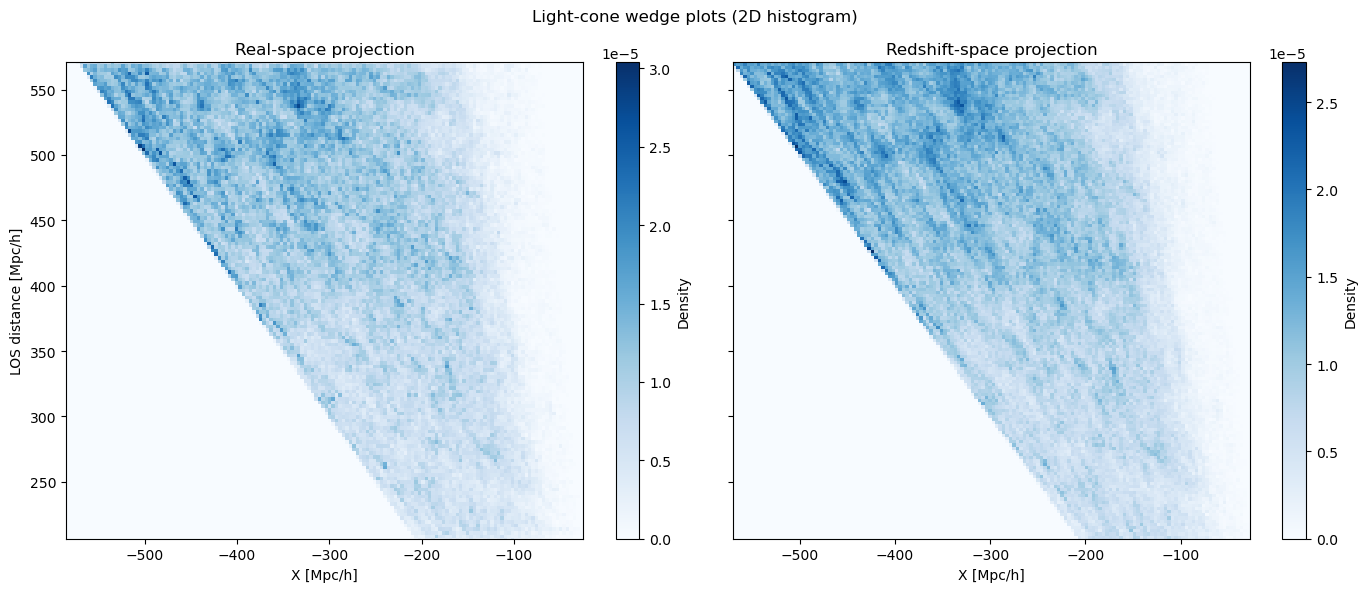

In [ ]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d

h = 1
Om0 = 0.31

# ============================================================
# 1. Build angular mask from random catalog (chunked)
# ============================================================
nside = 256
npix = hp.nside2npix(nside)
counts = np.zeros(npix, dtype=np.int32)   # counter array

chunksize_rand = 5_000_000
for chunk in pd.read_csv("../data/lss_randoms_combined_cut_LARGE.csv",
                         usecols=['ra', 'dec'],
                         dtype={'ra': 'float32', 'dec': 'float32'},
                         chunksize=chunksize_rand):
    pix = hp.ang2pix(nside, chunk['ra'].values, chunk['dec'].values, lonlat=True, nest=True)
    np.add.at(counts, pix, 1)
    del chunk, pix

min_rand = 5
mask_pix = counts >= min_rand

# ============================================================
# 2. Process galaxy file in chunks with periodic tiling
# ============================================================
main_cols = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'magstarsdssr']
# Use int64 for ID to keep exact values
dtype_main = {col: 'float32' for col in main_cols}

df_fil = pd.read_csv("../data/mock_withfilament.csv", usecols=['dfil'])
if 'dist_fil' in df_fil.columns:
    dist_fil_all = df_fil['dist_fil'].values
elif 'dfil' in df_fil.columns:
    dist_fil_all = df_fil['dfil'].values
else:
    raise ValueError("No dist_fil/dfil column")

# Cosmology with H0=100 (so distances are in Mpc/h)
cosmo = FlatLambdaCDM(H0=100, Om0=Om0)
z_grid = np.linspace(0, 1, 1000)
r_grid = cosmo.comoving_distance(z_grid).value
r_to_z = interp1d(r_grid, z_grid, bounds_error=False, fill_value="extrapolate")
c = 3e5  # km/s

# Maximum distance to consider (from z=0.2, safe upper bound)
z_max = 0.22
R_max = cosmo.comoving_distance(z_max).value   # Mpc/h

# Precompute all possible box shifts (only -1,0,1 because R_max < L)
n = np.array([-1, 0, 1])
nx_arr, ny_arr, nz_arr = np.meshgrid(n, n, n, indexing='ij')
nx_arr = nx_arr.flatten()
ny_arr = ny_arr.flatten()
nz_arr = nz_arr.flatten()
n_copies = len(nx_arr)   # = 27

survivors = []
chunksize_gal = 1_000_000
start_idx = 0
L = 1000.0

for chunk in pd.read_csv("../data/to_mock.csv",
                         usecols=main_cols,
                         dtype=dtype_main,
                         chunksize=chunksize_gal):
    # Extract arrays
    x = chunk['x'].values
    y = chunk['y'].values
    z = chunk['z'].values
    vx = chunk['vx'].values
    vy = chunk['vy'].values
    vz = chunk['vz'].values
    mag_r = chunk['magstarsdssr'].values

    # Corresponding filament distances for this chunk
    end_idx = start_idx + len(chunk)
    dist_fil_chunk = dist_fil_all[start_idx:end_idx]
    start_idx = end_idx

    # Center coordinates around observer
    x_c = x - L/2
    y_c = y - L/2
    z_c = z - L/2

    N_gal = len(x_c)

    # Process in batches to keep memory under control
    batch_size = 10000
    for i in range(0, N_gal, batch_size):
        idx_slice = slice(i, min(i+batch_size, N_gal))
        xc_b = x_c[idx_slice]
        yc_b = y_c[idx_slice]
        zc_b = z_c[idx_slice]
        vx_b = vx[idx_slice]
        vy_b = vy[idx_slice]
        vz_b = vz[idx_slice]
        mag_b = mag_r[idx_slice]
        dist_b = dist_fil_chunk[idx_slice]

        # Expand to (batch_size, n_copies)
        x_shifted = xc_b[:, np.newaxis] + nx_arr * L
        y_shifted = yc_b[:, np.newaxis] + ny_arr * L
        z_shifted = zc_b[:, np.newaxis] + nz_arr * L
        r = np.sqrt(x_shifted**2 + y_shifted**2 + z_shifted**2)

        # Keep only copies within R_max
        valid = r <= R_max
        if not np.any(valid):
            continue

        # Flatten valid entries
        flat_valid = valid.flatten()
        x_flat = x_shifted.flatten()[flat_valid]
        y_flat = y_shifted.flatten()[flat_valid]
        z_flat = z_shifted.flatten()[flat_valid]
        r_flat = r.flatten()[flat_valid]

        # Map each flat entry back to its original galaxy (for velocities, magnitudes, distances, and ID)
        gal_idx = np.tile(np.arange(len(xc_b)), n_copies)[flat_valid]
        vx_flat = vx_b[gal_idx]
        vy_flat = vy_b[gal_idx]
        vz_flat = vz_b[gal_idx]
        mag_flat = mag_b[gal_idx]
        dist_flat = dist_b[gal_idx]

        # Compute angles
        ra_rad = np.arctan2(y_flat, x_flat)
        ra_deg = np.degrees(ra_rad)
        ra_deg = np.mod(ra_deg, 360.0)
        dec_rad = np.arcsin(z_flat / r_flat)
        dec_deg = np.degrees(dec_rad)

        # Cosmological redshift
        z_cosmo_flat = r_to_z(r_flat)

        # LOS velocities
        nx_flat = x_flat / r_flat
        ny_flat = y_flat / r_flat
        nz_flat = z_flat / r_flat
        v_los_flat = vx_flat * nx_flat + vy_flat * ny_flat + vz_flat * nz_flat
        z_obs_flat = z_cosmo_flat + v_los_flat / c

        # Apply initial cuts (redshift + magnitude)
        mask_z_mag = (z_obs_flat > 0.05) & (z_obs_flat < 0.22) & (mag_flat < -20.5)
        if not np.any(mask_z_mag):
            continue

        # Apply mask to all arrays
        x_flat = x_flat[mask_z_mag]
        y_flat = y_flat[mask_z_mag]
        z_flat = z_flat[mask_z_mag]
        ra_deg = ra_deg[mask_z_mag]
        dec_deg = dec_deg[mask_z_mag]
        ra_rad = ra_rad[mask_z_mag]
        dec_rad = dec_rad[mask_z_mag]
        z_cosmo_flat = z_cosmo_flat[mask_z_mag]
        z_obs_flat = z_obs_flat[mask_z_mag]
        mag_flat = mag_flat[mask_z_mag]
        dist_flat = dist_flat[mask_z_mag]

        # Angular mask
        theta_gal = np.pi/2.0 - dec_rad
        phi_gal = ra_rad
        pix_gal = hp.ang2pix(nside, theta_gal, phi_gal, nest=True)
        mask_ang = mask_pix[pix_gal]
        if not np.any(mask_ang):
            continue

        # Apply angular mask
        x_flat = x_flat[mask_ang]
        y_flat = y_flat[mask_ang]
        z_flat = z_flat[mask_ang]
        ra_deg = ra_deg[mask_ang]
        dec_deg = dec_deg[mask_ang]
        ra_rad = ra_rad[mask_ang]
        dec_rad = dec_rad[mask_ang]
        z_cosmo_flat = z_cosmo_flat[mask_ang]
        z_obs_flat = z_obs_flat[mask_ang]
        mag_flat = mag_flat[mask_ang]
        dist_flat = dist_flat[mask_ang]

        # Redshift-space positions
        r_obs_flat = cosmo.comoving_distance(z_obs_flat).value
        # Recompute unit vectors (they have changed due to mask)
        nx_flat = x_flat / np.sqrt(x_flat**2 + y_flat**2 + z_flat**2)
        ny_flat = y_flat / np.sqrt(x_flat**2 + y_flat**2 + z_flat**2)
        nz_flat = z_flat / np.sqrt(x_flat**2 + y_flat**2 + z_flat**2)
        x_rsd = r_obs_flat * nx_flat
        y_rsd = r_obs_flat * ny_flat
        z_rsd = r_obs_flat * nz_flat

        # Collect survivors
        chunk_survivors = pd.DataFrame({
            'x_real': x_flat,
            'y_real': y_flat,
            'z_real': z_flat,
            'x_rsd': x_rsd,
            'y_rsd': y_rsd,
            'z_rsd': z_rsd,
            'ra_deg': ra_deg,
            'dec_deg': dec_deg,
            'z_cosmo': z_cosmo_flat,
            'z_obs': z_obs_flat,
            'dist_fil': dist_flat,
            'mag_r': mag_flat
        })
        survivors.append(chunk_survivors)

    # Free memory of this chunk
    del chunk, x_c, y_c, z_c, vx, vy, vz, mag_r, dist_fil_chunk

# ============================================================
# 3. Combine all survivors
# ============================================================
if not survivors:
    print("No galaxies passed the cuts.")
    exit()

out_df = pd.concat(survivors, ignore_index=True)
# Final redshift cut (tighten to avoid edge effects)
out_df = out_df[(out_df['z_obs'] > 0.07) & (out_df['z_obs'] < 0.2)]
print(f"Number of galaxies: {len(out_df)}")

# ============================================================
# 4. Save and plot (same as before)
# ============================================================
output_file = "../data/lightcone_real_and_rsd_withfil.csv"
out_df.to_csv(output_file, index=False)
print(f"Saved lightcone to: {output_file}")

# Diagnostics
print("Real space: x_c range: [{:.1f}, {:.1f}]".format(out_df['x_real'].min(), out_df['x_real'].max()))
print("Real space: r range: [{:.1f}, {:.1f}]".format(
    np.sqrt(out_df['x_real']**2+out_df['y_real']**2+out_df['z_real']**2).min(),
    np.sqrt(out_df['x_real']**2+out_df['y_real']**2+out_df['z_real']**2).max()))
print("Redshift space: x_rsd range: [{:.1f}, {:.1f}]".format(out_df['x_rsd'].min(), out_df['x_rsd'].max()))
print("Redshift space: r_obs range: [{:.1f}, {:.1f}]".format(
    np.sqrt(out_df['x_rsd']**2+out_df['y_rsd']**2+out_df['z_rsd']**2).min(),
    np.sqrt(out_df['x_rsd']**2+out_df['y_rsd']**2+out_df['z_rsd']**2).max()))

# ============================================================
# Plots (unchanged)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# RA/Dec plot using stored degrees
plt.figure(figsize=(10,6))
plt.scatter(out_df['ra_deg'], out_df['dec_deg'], s=1, alpha=0.5)
plt.title("Light-cone sky projection (RA/Dec)")
plt.grid(True)
plt.savefig('../plots/lightcone_ra_dec.png', dpi=100)
plt.show()

# Redshift distribution
plt.figure(figsize=(10,6))
bins = np.linspace(0.05, 0.22, 51)
print(min(out_df['z_obs']), max(out_df['z_obs']), min(out_df['z_cosmo']), max(out_df['z_cosmo']))
plt.hist(out_df['z_obs'], bins=bins, histtype='step', lw=3, label='Observed z')
plt.hist(out_df['z_cosmo'], bins=bins, histtype='step', lw=3, ls='--', label='Cosmological z')
plt.ylabel("Number of Galaxies")
plt.legend()
plt.title("Redshift distribution of light-cone")
plt.grid(True)
plt.savefig('../plots/lightcone_redshift_distribution.png', dpi=100)
plt.show()

# Real-space distance distribution
r_real = np.sqrt(out_df['x_real']**2 + out_df['y_real']**2 + out_df['z_real']**2)
plt.figure(figsize=(10,6))
plt.hist(r_real, bins=50)
plt.xlabel("Real-space distance [Mpc/h]")
plt.ylabel("Number of Galaxies")
plt.title("Distribution of real-space distances")
plt.grid(True)
plt.show()

# Wedge plots (unchanged)
r_obs = np.sqrt(out_df['x_rsd']**2 + out_df['y_rsd']**2 + out_df['z_rsd']**2)
N_plot = min(5_000_000, len(out_df))
idx = np.random.choice(len(out_df), size=N_plot, replace=False)

x_trans_real = out_df['x_real'].values[idx]
x_trans_rsd  = out_df['x_rsd'].values[idx]
r_los_real = r_real.values[idx]
r_los_rsd  = r_obs.values[idx]

bins_x = 150
bins_y = 150
vmin = None
vmax = None

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

h0 = axes[0].hist2d(x_trans_real, r_los_real, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[0].set_xlabel("X [Mpc/h]")
axes[0].set_ylabel("LOS distance [Mpc/h]")
axes[0].set_title("Real-space projection")

h1 = axes[1].hist2d(x_trans_rsd, r_los_rsd, bins=[bins_x, bins_y],
                     cmap='Blues', density=True, vmin=vmin, vmax=vmax)
axes[1].set_xlabel("X [Mpc/h]")
axes[1].set_title("Redshift-space projection")

fig.colorbar(h0[3], ax=axes[0], label="Density")
fig.colorbar(h1[3], ax=axes[1], label="Density")

plt.suptitle("Light-cone wedge plots (2D histogram)")
plt.tight_layout()
plt.savefig("../plots/lightcone_wedge_plots.png", dpi=100)
plt.show()